In [ ]:
%reload_ext autoreload
%autoreload 2
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=2, seed=42)
controller = Controller(sim)

vision_signal = []
olfactory_signal = []
for _ in trange(100000): #10000
    joint_angles, adhesion = controller.step(sim)
    vision_signal.append(controller.vision.current_signal)
    olfactory_signal.append(controller.olfaction.current_signal)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

100%|██████████| 50000/50000 [02:10<00:00, 384.08it/s]


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

vision_signal = np.asarray(vision_signal)
olfactory_signal = np.asarray(olfactory_signal)
x = np.arange(len(vision_signal))

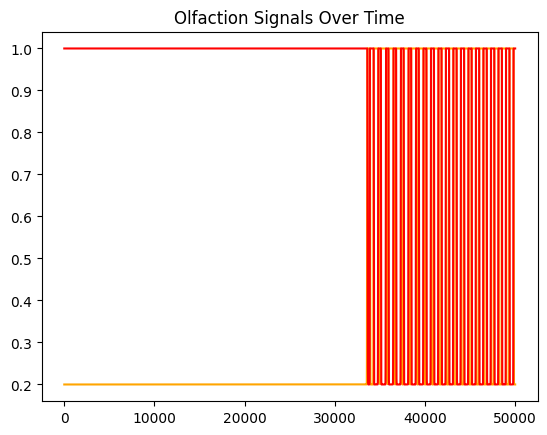

In [3]:
plt.figure()
plt.plot(x, olfactory_signal[:,0], color="orange", label="smell left drive")
plt.plot(x, olfactory_signal[:,1], color="red", label="smell right drive")
plt.title("Olfaction Signals Over Time")
plt.show()

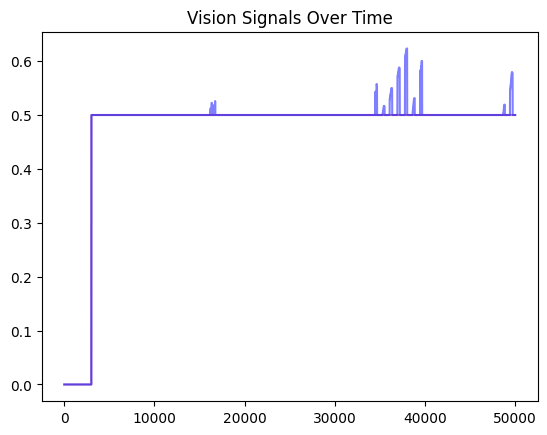

In [4]:
plt.figure()
plt.plot(x, vision_signal[:,0], color="purple", label="vision left drive", alpha=0.5)
plt.plot(x, vision_signal[:,1], color="blue", label="vision right drive", alpha=0.5)
#plt.plot(x, np.abs(vision_signal[:,1] - vision_signal[:,0]), color="red", label="vision right drive")
plt.title("Vision Signals Over Time")
plt.show()

In [ ]:
controller.olfaction.olfaction_smooth, sim.get_olfaction(sim.fly.name)

(array([[3.02365859e-08],
        [2.77959536e-08],
        [2.76207044e-08],
        [2.71062224e-08]]),
 array([[3.04457004e-08],
        [2.79823251e-08],
        [2.78146843e-08],
        [2.72956509e-08]]))

In [ ]:
sim.get_antenna_data(sim.fly.name).keys()

dict_keys(['l', 'r'])

In [ ]:
sim.get_antenna_data(sim.fly.name)['l'].keys()

dict_keys(['qpos', 'qvel', 'qacc', 'qfrc_passive'])

In [ ]:
sim.get_antenna_data(sim.fly.name)['l']['qvel']

array([-0.12694573, -0.09150428, -0.02246473])